In [5]:
import pandas as pd

df = pd.read_csv("Fake.csv", encoding='latin1')

In [6]:
df.head()

,Title,Location,Requirements,Employment_Type,Industry,Function,Fraudulent
0,Lead Ux / Ui Designer,"US, NY, Brookyn",4+ years of experience in UX / UI design prefe...,Full-time,Internet,Design,0
1,Technical Manager,"GB, CAM, Huntingdon",Food Science/Technology Graduate or similar di...,Full-time,Food Production,Quality Assurance,0
2,Quality Engineer,"US, OH, cincinnati",Job Duties and Responsibilities:AnalysisPerfor...,Full-time,Medical Devices,Engineering,0
3,"International Broadcaster, Lao Service","US, DC, Washington",The International Broadcaster shall have at le...,Not Mentioned,Not Mentioned,Not Mentioned,0
4,Distribution Specialist,"NL, NB, Eindhoven",Experience in professional logistic/warehouse ...,Full-time,Internet,Distribution,0


In [7]:
df.shape

(17880, 7)

In [8]:
df.columns

Index(['Title', 'Location', 'Requirements', 'Employment_Type', 'Industry',
       'Function', 'Fraudulent'],
      dtype='str')

In [9]:
df.isnull().sum()

Title              0
Location           0
Requirements       3
Employment_Type    0
Industry           0
Function           0
Fraudulent         0
dtype: int64

In [10]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Title            17880 non-null  str  
 1   Location         17880 non-null  str  
 2   Requirements     17877 non-null  str  
 3   Employment_Type  17880 non-null  str  
 4   Industry         17880 non-null  str  
 5   Function         17880 non-null  str  
 6   Fraudulent       17880 non-null  int64
dtypes: int64(1), str(6)
memory usage: 977.9 KB


In [13]:
df['text'] = df['Title'] + " " + df['Requirements']

In [14]:
df[['Title', 'Requirements', 'text']].head()

,Title,Requirements,text
0,Lead Ux / Ui Designer,4+ years of experience in UX / UI design prefe...,Lead Ux / Ui Designer 4+ years of experience i...
1,Technical Manager,Food Science/Technology Graduate or similar di...,Technical Manager Food Science/Technology Grad...
2,Quality Engineer,Job Duties and Responsibilities:AnalysisPerfor...,Quality Engineer Job Duties and Responsibiliti...
3,"International Broadcaster, Lao Service",The International Broadcaster shall have at le...,"International Broadcaster, Lao Service The Int..."
4,Distribution Specialist,Experience in professional logistic/warehouse ...,Distribution Specialist Experience in professi...


In [17]:
df['text'] = df['Title'].astype(str) + " " + df['Requirements'].astype(str)

df[['Title', 'Requirements', 'text']].head()

,Title,Requirements,text
0,Lead Ux / Ui Designer,4+ years of experience in UX / UI design prefe...,Lead Ux / Ui Designer 4+ years of experience i...
1,Technical Manager,Food Science/Technology Graduate or similar di...,Technical Manager Food Science/Technology Grad...
2,Quality Engineer,Job Duties and Responsibilities:AnalysisPerfor...,Quality Engineer Job Duties and Responsibiliti...
3,"International Broadcaster, Lao Service",The International Broadcaster shall have at le...,"International Broadcaster, Lao Service The Int..."
4,Distribution Specialist,Experience in professional logistic/warehouse ...,Distribution Specialist Experience in professi...


In [18]:
df['text'] = df['text'].str.lower()

In [19]:
df['text'] = df['text'].str.lower()

In [20]:
df['text'].head()

0    lead ux / ui designer 4+ years of experience i...
1    technical manager food science/technology grad...
2    quality engineer job duties and responsibiliti...
3    international broadcaster, lao service the int...
4    distribution specialist experience in professi...
Name: text, dtype: str

In [22]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ibrahim\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [24]:
import sys
print(sys.executable)

c:\Program Files\Python314\python.exe


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [27]:
tfidf = TfidfVectorizer(max_features=5000)

In [29]:
df['text'] = df['text'].fillna('')
df['text'] = df['text'].astype(str)

In [30]:
X = tfidf.fit_transform(df['text'])

In [33]:
df.columns

Index(['Title', 'Location', 'Requirements', 'Employment_Type', 'Industry',
       'Function', 'Fraudulent', 'text'],
      dtype='str')

In [34]:
df.columns = df.columns.str.strip().str.lower()

In [35]:
df['text'] = df['title'].astype(str) + " " + df['requirements'].astype(str)

In [36]:
df['text'] = df['text'].fillna('').astype(str)

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['text'])

y = df['fraudulent']

In [38]:
X.shape

(17880, 5000)

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [40]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(14304, 5000)
(3576, 5000)
(14304,)
(3576,)


In [41]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [42]:
y_pred = model.predict(X_test)

In [43]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9628076062639821


In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      3403
           1       1.00      0.23      0.38       173

    accuracy                           0.96      3576
   macro avg       0.98      0.62      0.68      3576
weighted avg       0.96      0.96      0.95      3576



In [45]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[3403    0]
 [ 133   40]]


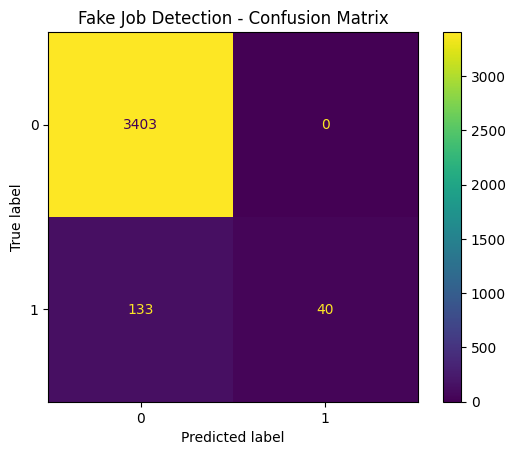

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

plt.title("Fake Job Detection - Confusion Matrix")
plt.show()

In [51]:
sample_job = """
Work from home data entry job.
Earn $200 daily.
No experience required.
Urgent hiring now.
"""

In [52]:
sample_vector = tfidf.transform([sample_job])

In [53]:
prediction = model.predict(sample_vector)

print(prediction)

[1]


In [54]:
if prediction[0] == 1:
    print("Prediction: Fake Job Posting")
else:
    print("Prediction: Real Job Posting")

Prediction: Fake Job Posting


In [55]:
job1 = """
Work from home typing job.
Earn $500 daily.
No experience needed.
Immediate joining.
"""

vec1 = tfidf.transform([job1])

pred1 = model.predict(vec1)

if pred1[0] == 1:
    print("Fake Job Posting")
else:
    print("Real Job Posting")

Fake Job Posting


In [56]:
job2 = """
Data Analyst required with experience in SQL, Excel, and Power BI.
Candidate should analyze business data, create dashboards, and prepare reports.
Bachelor degree in computer science or related field preferred.
"""

vec2 = tfidf.transform([job2])
pred2 = model.predict(vec2)

if pred2[0] == 1:
    print("Fake Job Posting")
else:
    print("Real Job Posting")

Real Job Posting


In [57]:
import joblib

In [58]:
joblib.dump(model, "fake_job_model.pkl")

['fake_job_model.pkl']

In [59]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [60]:
loaded_model = joblib.load("fake_job_model.pkl")
loaded_tfidf = joblib.load("tfidf_vectorizer.pkl")

In [61]:
new_job = """
Urgent work from home data entry job.
Earn daily income.
No experience required.
"""

new_vector = loaded_tfidf.transform([new_job])
new_prediction = loaded_model.predict(new_vector)

if new_prediction[0] == 1:
    print("Fake Job Posting")
else:
    print("Real Job Posting")

Fake Job Posting
